In [247]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# The Goal

Looking at our datasets to see which features along the chain (solar flare → CME → solar wind → geomagnetic storm) relate to storm occurrence (`is_storm`). The point is to find which features carry real signal for the model and which are just noise we can drop.

In [248]:
solar_flare_events=pd.read_parquet('../data/clean-data/solar-flare-events.parquet')
omni_solar_wind_parameters=pd.read_parquet('../data/omni-solar-wind-parameters/omni_solar_wind_parameters.parquet')
donki_space_weather_events=pd.read_parquet('../data/donki-space-weather-events/donki_events.parquet')
space_weather_indices=pd.read_parquet('../data/space-weather-indices/space_weather_indices.parquet')


# Thoughts on what I can check

check correlation of `is_storm` with upstream variables from each dataset (skip `solar-wind/` — only starts 2026, too short).

reminder: skip the geomagnetic *response* columns, they leak the target — `ap_*`, `kp_*`, `kp_sum`, `cp`, `c9`, `storm_level`, and OMNI `kp_index`/`ap_index_nt`/`dst_index_nt`/`ae_index_nt`/`al_index_nt`/`au_index_nt`/`pc_n_index`.

**omni-solar-wind-parameters** (main feature source, hourly → aggregate to daily, use min/max not just mean):

- `bz_gsm_nt` — THE driver; southward (negative) Bz opens the magnetosphere. use `min(Bz)` over the day or `Bs = max(0, -Bz)`
- `electric_field_mvpm` — speed × southward field; the storm driver in operational models
- `flow_speed_kms` — fast wind = more energy in
- `b_magnitude_vector_nt` — more total field = more to reconnect
- `flow_pressure_npa` — ram pressure compresses the magnetosphere
- `proton_density_cm3` — feeds pressure + ring current (weaker)
- `by_gsm_nt` — Russell–McPherron seasonal projection onto Bz (weak)
- engineered coupling functions (Newell, VBs, Akasofu ε) — combine speed + field; usually beat any single raw column

**space-weather-indices** (target lives here, only F10.7 / sunspot are usable):

- `f107_obs` / `f107_adj` (+ 81-day means), `sunspot_number` — solar-cycle phase; sets the base rate of storms, weak same-day trigger

**solar-flare-events** (GOES, 2017+; lag features ~1–3 days, it's the CME not the X-rays that drives the storm):

- `peak_flux_wm2` / `goes_class` — M/X flares flag an active Sun / CME likelihood (noisy proxy)
- flare duration (`end_time - start_time`) — long-duration events tie to CMEs

**donki-space-weather-events** (2010+; lag ~1–3 days):

- `cme_speed_kms` — dominant control on big storms
- `cme_half_angle_deg` — halo (wide) CMEs are the Earth-directed ones
- `cme_latitude` / `cme_longitude` / `source_location` — is it aimed at Earth
- event counts by type (CME/HSS/SEP) — overall activity level

In [249]:
space_weather_indices.info()

<class 'pandas.DataFrame'>
RangeIndex: 25322 entries, 0 to 25321
Data columns (total 34 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               25322 non-null  datetime64[us]
 1   bartels_rotation   25322 non-null  int64         
 2   bartels_day        25322 non-null  int64         
 3   kp_0000            25139 non-null  float64       
 4   kp_0300            25139 non-null  float64       
 5   kp_0600            25139 non-null  float64       
 6   kp_0900            25139 non-null  float64       
 7   kp_1200            25139 non-null  float64       
 8   kp_1500            25139 non-null  float64       
 9   kp_1800            25139 non-null  float64       
 10  kp_2100            25139 non-null  float64       
 11  kp_sum             25139 non-null  float64       
 12  ap_0000            25139 non-null  float64       
 13  ap_0300            25139 non-null  float64       
 14  ap_0600          

In [250]:
space_weather_indices.head()

,date,bartels_rotation,bartels_day,kp_0000,kp_0300,kp_0600,kp_0900,kp_1200,kp_1500,kp_1800,...,f107_obs,f107_adj,f107_data_type,f107_obs_center81,f107_obs_last81,f107_adj_center81,f107_adj_last81,is_storm,storm_level,data_type
0,1957-10-01,1700,19,43.0,40.0,30.0,20.0,37.0,23.0,43.0,...,269.3,269.8,OBS,266.6,230.9,266.8,235.5,False,G5,observed
1,1957-10-02,1700,20,37.0,37.0,17.0,17.0,27.0,23.0,17.0,...,253.3,253.6,OBS,267.4,231.7,267.5,236.2,False,G5,observed
2,1957-10-03,1700,21,27.0,20.0,13.0,33.0,37.0,47.0,43.0,...,266.3,266.4,OBS,268.1,232.7,268.1,237.1,False,G5,observed
3,1957-10-04,1700,22,30.0,30.0,23.0,27.0,23.0,27.0,30.0,...,238.2,238.2,OBS,268.8,233.3,268.7,237.7,False,G5,observed
4,1957-10-05,1700,23,30.0,30.0,17.0,23.0,20.0,27.0,27.0,...,246.2,246.0,OBS,269.3,233.9,269.1,238.1,False,G5,observed


In [251]:
solar_flare_events.head()

,satellite,start_time,peak_time,peak_flux_wm2,goes_class,end_time,goes_class_letter,duration_minutes,end_time_imputed,log_peak_flux,duration_outlier,flux_outlier
0,GOES-16,2017-02-09 00:41:00,2017-02-09 00:50:00,3.711663e-07,B3.7,2017-02-09 00:56:00,B,15.0,0,-6.430431,False,False
1,GOES-16,2017-02-09 01:30:00,2017-02-09 01:40:00,4.310535e-07,B4.3,2017-02-09 01:42:00,B,12.0,0,-6.365469,False,False
2,GOES-16,2017-02-09 01:45:00,2017-02-09 01:51:00,1.694939e-06,C1.6,2017-02-09 01:55:00,C,10.0,0,-5.770846,False,False
3,GOES-16,2017-02-09 02:31:00,2017-02-09 02:40:00,3.234027e-07,B3.2,2017-02-09 02:48:00,B,17.0,0,-6.490256,False,False
4,GOES-16,2017-02-09 02:55:00,2017-02-09 02:59:00,3.839661e-07,B3.8,2017-02-09 03:08:00,B,13.0,1,-6.415707,False,False


In [252]:
solar_flare_events.info()

<class 'pandas.DataFrame'>
Index: 16085 entries, 0 to 16110
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   satellite          16085 non-null  string        
 1   start_time         16085 non-null  datetime64[us]
 2   peak_time          16085 non-null  datetime64[us]
 3   peak_flux_wm2      16085 non-null  float64       
 4   goes_class         16085 non-null  string        
 5   end_time           16085 non-null  datetime64[us]
 6   goes_class_letter  16085 non-null  string        
 7   duration_minutes   16085 non-null  float64       
 8   end_time_imputed   16085 non-null  int64         
 9   log_peak_flux      16085 non-null  float64       
 10  duration_outlier   16085 non-null  bool          
 11  flux_outlier       16085 non-null  bool          
dtypes: bool(2), datetime64[us](3), float64(3), int64(1), string(3)
memory usage: 1.6 MB


In [253]:
solar_flare_events['date']=solar_flare_events['start_time'].dt.normalize()
solar_flare_events.head()

,satellite,start_time,peak_time,peak_flux_wm2,goes_class,end_time,goes_class_letter,duration_minutes,end_time_imputed,log_peak_flux,duration_outlier,flux_outlier,date
0,GOES-16,2017-02-09 00:41:00,2017-02-09 00:50:00,3.711663e-07,B3.7,2017-02-09 00:56:00,B,15.0,0,-6.430431,False,False,2017-02-09
1,GOES-16,2017-02-09 01:30:00,2017-02-09 01:40:00,4.310535e-07,B4.3,2017-02-09 01:42:00,B,12.0,0,-6.365469,False,False,2017-02-09
2,GOES-16,2017-02-09 01:45:00,2017-02-09 01:51:00,1.694939e-06,C1.6,2017-02-09 01:55:00,C,10.0,0,-5.770846,False,False,2017-02-09
3,GOES-16,2017-02-09 02:31:00,2017-02-09 02:40:00,3.234027e-07,B3.2,2017-02-09 02:48:00,B,17.0,0,-6.490256,False,False,2017-02-09
4,GOES-16,2017-02-09 02:55:00,2017-02-09 02:59:00,3.839661e-07,B3.8,2017-02-09 03:08:00,B,13.0,1,-6.415707,False,False,2017-02-09


In [254]:
solar_flare_events=solar_flare_events.sort_values('start_time')

# calculating time between the events in hours
time_between_events=solar_flare_events['start_time'].diff().dt.total_seconds() / 3600
time_between_events.describe()

count    16084.000000
mean         4.444858
std         38.527540
min          0.066667
25%          0.616667
50%          1.483333
75%          3.250000
max       2434.233333
Name: start_time, dtype: float64

In [255]:
print(len(space_weather_indices['date']))
print(space_weather_indices['date'].nunique())

25322
25322


In `solar-flare-events` there are usually several flares per day, while `space_weather_indices` has one row per day (all unique days). So we aggregate flares to one row per day before merging.

In [256]:
solar_flare_events.columns

Index(['satellite', 'start_time', 'peak_time', 'peak_flux_wm2', 'goes_class',
       'end_time', 'goes_class_letter', 'duration_minutes', 'end_time_imputed',
       'log_peak_flux', 'duration_outlier', 'flux_outlier', 'date'],
      dtype='str')

In [257]:
# Collapse flares to one row per day: how many, how strong, M/X count, longest.
daily_flares=solar_flare_events.groupby('date').agg(
    flare_count=('goes_class', 'size'),
    max_peak_flux_wm2=('peak_flux_wm2', 'max'),
    max_log_peak_flux=('log_peak_flux', 'max'),
    mx_flare_count=('goes_class_letter', lambda s: s.isin(['M', 'X']).sum()),
    max_duration_minutes=('duration_minutes', 'max'),
    total_duration_minutes=('duration_minutes', 'sum')
).reset_index()

daily_flares

,date,flare_count,max_peak_flux_wm2,max_log_peak_flux,mx_flare_count,max_duration_minutes,total_duration_minutes
0,2017-02-09,19,2.043853e-06,-5.689550,0,21.0,239.0
1,2017-02-12,2,1.728716e-07,-6.762276,0,15.0,30.0
2,2017-02-13,1,2.133511e-07,-6.670905,0,28.0,28.0
3,2017-02-15,1,2.987244e-07,-6.524729,0,15.0,15.0
4,2017-02-17,3,1.752361e-07,-6.756376,0,31.0,50.0
...,...,...,...,...,...,...,...
1892,2025-04-02,11,8.096307e-06,-5.091713,0,31.0,155.0
1893,2025-04-03,4,3.459028e-06,-5.461046,0,26.0,53.0
1894,2025-04-04,5,5.745445e-06,-5.240676,0,42.0,109.0
1895,2025-04-05,10,1.050863e-05,-4.978454,1,18.0,113.0


In [258]:
# Start with the first date in solar-flare-events dataset 
flare_start=daily_flares['date'].min()
recent_indices=space_weather_indices[space_weather_indices['date']>=flare_start]
recent_indices

,date,bartels_rotation,bartels_day,kp_0000,kp_0300,kp_0600,kp_0900,kp_1200,kp_1500,kp_1800,...,f107_obs,f107_adj,f107_data_type,f107_obs_center81,f107_obs_last81,f107_adj_center81,f107_adj_last81,is_storm,storm_level,data_type
21681,2017-02-09,2503,19,20.0,13.0,10.0,17.0,10.0,20.0,23.0,...,73.4,71.5,OBS,75.8,76.5,74.0,74.2,False,G5,observed
21682,2017-02-10,2503,20,23.0,10.0,20.0,13.0,20.0,23.0,13.0,...,74.0,72.1,OBS,75.8,76.5,74.0,74.2,False,G5,observed
21683,2017-02-11,2503,21,27.0,10.0,7.0,7.0,3.0,0.0,7.0,...,75.7,73.8,OBS,75.8,76.5,74.0,74.2,False,G5,observed
21684,2017-02-12,2503,22,7.0,0.0,3.0,3.0,3.0,13.0,17.0,...,76.2,74.3,OBS,75.8,76.5,74.0,74.1,False,G5,observed
21685,2017-02-13,2503,23,23.0,13.0,3.0,7.0,3.0,20.0,17.0,...,74.8,73.0,OBS,75.8,76.4,74.1,74.1,False,G5,observed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25317,2041-06-01,2832,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,69.2,71.1,PRM,69.5,71.1,71.3,71.7,False,NaN,predicted
25318,2041-07-01,2833,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,68.5,70.8,PRM,68.8,69.8,71.0,71.4,False,NaN,predicted
25319,2041-08-01,2834,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,68.4,70.5,PRM,68.7,69.0,70.6,71.1,False,NaN,predicted
25320,2041-09-01,2835,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,68.9,70.2,PRM,69.2,68.7,70.4,70.7,False,NaN,predicted


In [259]:
# Combining datasets: left merge, data is preserved even when there were no flares 
combined_datasets=recent_indices.merge(daily_flares, on='date', how='left')
combined_datasets.sample(10)

,date,bartels_rotation,bartels_day,kp_0000,kp_0300,kp_0600,kp_0900,kp_1200,kp_1500,kp_1800,...,f107_adj_last81,is_storm,storm_level,data_type,flare_count,max_peak_flux_wm2,max_log_peak_flux,mx_flare_count,max_duration_minutes,total_duration_minutes
779,2019-03-30,2532,15,20.0,13.0,3.0,3.0,7.0,3.0,3.0,...,69.7,False,G5,observed,<NA>,NaN,NaN,<NA>,NaN,NaN
81,2017-05-01,2506,19,23.0,20.0,0.0,3.0,3.0,7.0,13.0,...,77.4,False,G5,observed,<NA>,NaN,NaN,<NA>,NaN,NaN
1284,2020-08-16,2551,7,10.0,10.0,10.0,10.0,3.0,3.0,3.0,...,72.3,False,G5,observed,1,1.263213e-07,-6.898523,0,27.0,27.0
1830,2022-02-13,2571,13,37.0,30.0,23.0,27.0,30.0,33.0,23.0,...,102.3,False,G5,observed,12,7.145449e-06,-5.145970,0,26.0,184.0
2702,2024-07-04,2603,21,17.0,20.0,10.0,13.0,20.0,30.0,30.0,...,190.4,False,G5,observed,8,1.415107e-05,-4.849211,2,36.0,168.0
2868,2024-12-17,2609,25,37.0,53.0,50.0,43.0,33.0,40.0,20.0,...,200.2,False,G5,observed,7,5.934323e-06,-5.226629,0,30.0,113.0
1110,2020-02-24,2544,22,20.0,17.0,0.0,3.0,7.0,3.0,7.0,...,69.3,False,G5,observed,<NA>,NaN,NaN,<NA>,NaN,NaN
545,2018-08-08,2523,24,7.0,7.0,13.0,13.0,17.0,10.0,10.0,...,73.5,False,G5,observed,<NA>,NaN,NaN,<NA>,NaN,NaN
1993,2022-07-26,2577,14,33.0,20.0,3.0,17.0,17.0,10.0,10.0,...,131.6,False,G5,observed,9,8.559284e-06,-5.067563,0,34.0,127.0
1384,2020-11-24,2554,26,17.0,10.0,0.0,3.0,7.0,10.0,3.0,...,76.1,False,G5,observed,6,1.132400e-06,-5.946000,0,33.0,127.0


In [260]:
# Filling null flare columns to indicate that the data is not missing but there were no events that day
flare_columns=['flare_count', 'mx_flare_count']
combined_datasets[flare_columns]=combined_datasets[flare_columns].fillna(0)
combined_datasets.sample(5)

,date,bartels_rotation,bartels_day,kp_0000,kp_0300,kp_0600,kp_0900,kp_1200,kp_1500,kp_1800,...,f107_adj_last81,is_storm,storm_level,data_type,flare_count,max_peak_flux_wm2,max_log_peak_flux,mx_flare_count,max_duration_minutes,total_duration_minutes
2508,2023-12-23,2596,16,3.0,3.0,20.0,7.0,20.0,27.0,7.0,...,146.5,False,G5,observed,4,3.150055e-06,-5.501682,0,21.0,67.0
170,2017-07-29,2509,27,3.0,10.0,13.0,10.0,7.0,10.0,3.0,...,77.9,False,G5,observed,0,NaN,NaN,0,NaN,NaN
1876,2022-03-31,2573,5,47.0,47.0,37.0,37.0,47.0,43.0,23.0,...,110.7,False,G5,observed,13,9.672293e-05,-4.014471,1,32.0,213.0
1652,2021-08-19,2564,24,0.0,3.0,3.0,13.0,13.0,13.0,13.0,...,81.3,False,G5,observed,2,2.136527e-07,-6.670292,0,54.0,67.0
1593,2021-06-21,2562,19,7.0,3.0,0.0,7.0,10.0,10.0,13.0,...,77.0,False,G5,observed,1,1.215945e-07,-6.915086,0,11.0,11.0


In [261]:
combined_datasets.columns

Index(['date', 'bartels_rotation', 'bartels_day', 'kp_0000', 'kp_0300',
       'kp_0600', 'kp_0900', 'kp_1200', 'kp_1500', 'kp_1800', 'kp_2100',
       'kp_sum', 'ap_0000', 'ap_0300', 'ap_0600', 'ap_0900', 'ap_1200',
       'ap_1500', 'ap_1800', 'ap_2100', 'ap_avg', 'cp', 'c9', 'sunspot_number',
       'f107_obs', 'f107_adj', 'f107_data_type', 'f107_obs_center81',
       'f107_obs_last81', 'f107_adj_center81', 'f107_adj_last81', 'is_storm',
       'storm_level', 'data_type', 'flare_count', 'max_peak_flux_wm2',
       'max_log_peak_flux', 'mx_flare_count', 'max_duration_minutes',
       'total_duration_minutes'],
      dtype='str')

# space-weather-indices: what the solar-activity variables mean

These are all **proxies for how active the Sun is** — they track the ~11-year solar cycle, not the storm itself.

- **`f107_obs`** — F10.7 solar radio flux (10.7 cm), a stand-in for the Sun's EUV output. Low (~70 SFU) when quiet, high (200+) when active.
- **`f107_adj`** — same flux corrected for Earth's changing distance from the Sun. Nearly identical to `f107_obs` → keep only one.
- **81-day means (`*_center81`, `*_last81`)** — smooth out the 27-day rotation noise to show the background cycle level. `last81` only uses past data (safe to forecast with); `center81` peeks ahead.
- **`sunspot_number`** — daily sunspot count, the oldest solar-cycle tracker. Moves together with F10.7.

**Caveat:** these set the storm *base rate* (more storms near solar max) but don't trigger a storm on the same day — the real trigger (southward Bz) arrives 1–3 days after a CME. So expect **weak same-day correlation** with `is_storm`.

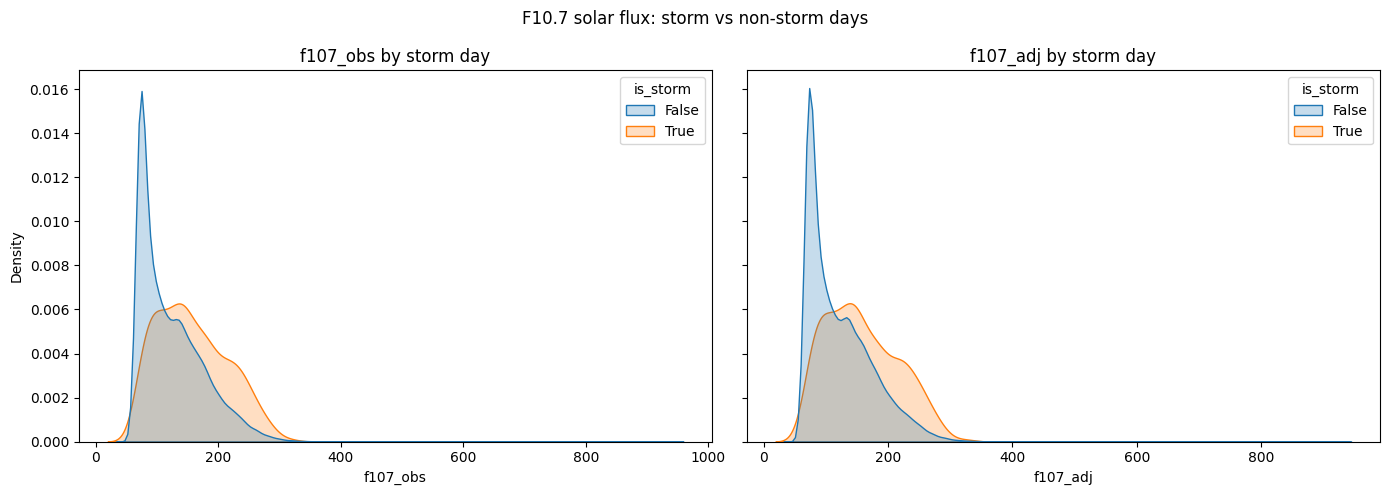

In [262]:
# Compare the F10.7 distribution on storm vs non-storm days, observed vs 1-AU-adjusted.
# common_norm=False scales each curve to its own area so the rare storm class stays visible.
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, col in zip(axes, ['f107_obs', 'f107_adj']):
    sns.kdeplot(data=space_weather_indices, x=col,
                hue='is_storm', common_norm=False, fill=True, ax=ax)
    ax.set_title(f'{col} by storm day')

fig.suptitle('F10.7 solar flux: storm vs non-storm days')
plt.tight_layout()
plt.show()

Each curve is the F10.7 distribution within its class (storm vs non-storm), scaled to its own area. Non-storm days peak at low activity (~70 SFU); storm days lean higher but **overlap heavily** — so F10.7 is at best a weak signal. The two panels look identical, confirming `f107_obs` and `f107_adj` are redundant (keep one).

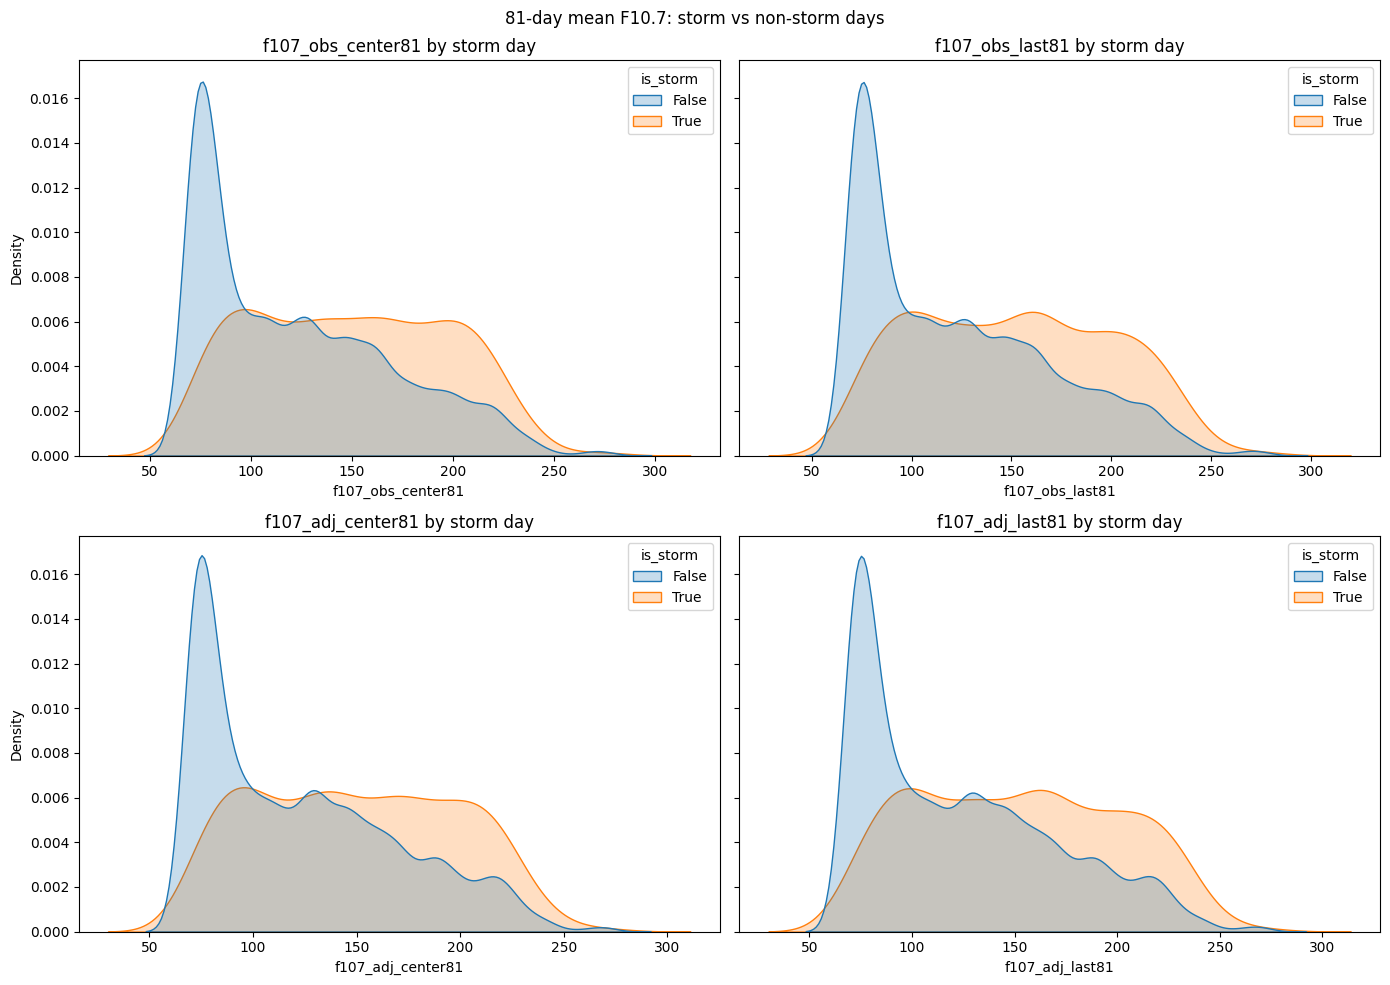

In [263]:
# Storm vs non-storm distributions for the four 81-day F10.7 means.
# These are smoothed to the solar-cycle background, so expect a cleaner storm/quiet split than raw f107.
mean_cols = ['f107_obs_center81', 'f107_obs_last81',
            'f107_adj_center81', 'f107_adj_last81']

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)

for ax, col in zip(axes.flat, mean_cols):
    sns.kdeplot(data=space_weather_indices, x=col,
                hue='is_storm', common_norm=False, fill=True, ax=ax)
    ax.set_title(f'{col} by storm day')

fig.suptitle('81-day mean F10.7: storm vs non-storm days')
plt.tight_layout()
plt.show()

Same story across all four panels: storm days sit slightly higher, but the curves overlap heavily. The 81-day means don't separate storm from quiet days any better than raw F10.7 — still a weak signal.

In [264]:
# Pearson and SPearman correlation for each feature
f107_cols = ['f107_obs', 'f107_adj', 'f107_obs_center81',
            'f107_obs_last81', 'f107_adj_center81', 'f107_adj_last81']
target = space_weather_indices['is_storm'].astype(int)
pd.DataFrame({
    'pearson': space_weather_indices[f107_cols].corrwith(target),
    'spearman': space_weather_indices[f107_cols].corrwith(target, method='spearman'),
}).sort_values('spearman', ascending=False)

,pearson,spearman
f107_adj,0.104600,0.100558
f107_obs,0.101788,0.099560
f107_adj_last81,0.095891,0.095244
f107_obs_last81,0.094094,0.094420
f107_adj_center81,0.090314,0.091576
f107_obs_center81,0.087744,0.090420


All correlations are ~0.1 (Pearson and Spearman agree) — a real but very weak signal. Not strong enough to rely on alone.

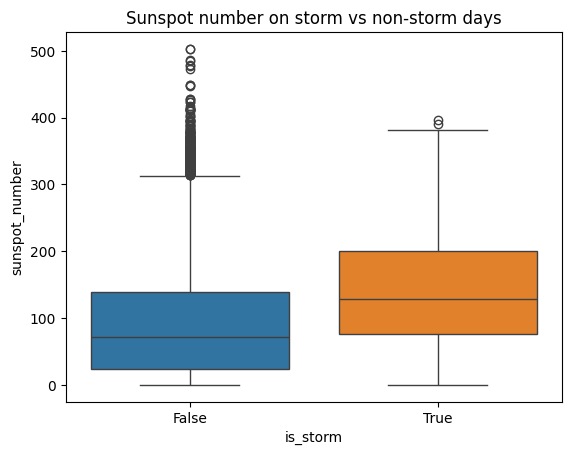

In [265]:
# Sunspot count on storm vs non-storm days.
# Box shows median + middle 50%; whiskers show the typical range, dots are outliers.
sns.boxplot(data=space_weather_indices, x='is_storm', y='sunspot_number', hue='is_storm', legend=False, palette=['tab:blue', 'tab:orange'])
plt.title('Sunspot number on storm vs non-storm days')
plt.show()

In [266]:
target = space_weather_indices['is_storm'].astype(int)
print('pearson :', space_weather_indices['sunspot_number'].corr(target))
print('spearman:', space_weather_indices['sunspot_number'].corr(target, method='spearman'))


pearson : 0.09746070184523911
spearman: 0.09537236105046419


In [267]:
# Group summaries: median, mean, spread of sunspot count for each class.
space_weather_indices.groupby('is_storm')['sunspot_number'].describe()

,count,mean,std,min,25%,50%,75%,max
is_storm,,,,,,,,
False,24709.0,89.685661,79.396387,0.0,23.0,71.0,139.0,503.0
True,613.0,140.368679,85.502348,0.0,76.0,129.0,200.0,397.0


Storm days have a higher median sunspot count (129 vs 71) and sit higher overall, but the boxes overlap a lot and the correlation is only ~0.10 — same weak base-rate signal as F10.7.